In [1]:
import kagglehub
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt

### Download English writing dataset

In [2]:

# Download latest version
path_english = kagglehub.dataset_download("tejasreddy/iam-handwriting-top50")

print("Path to dataset files:", path_english)

Path to dataset files: /Users/sasha/.cache/kagglehub/datasets/tejasreddy/iam-handwriting-top50/versions/2


### Download Arabic writing dataset

In [3]:
# Download latest version
path_arabic = kagglehub.dataset_download("humansintheloop/arabic-documents-ocr-dataset")

print("Path to dataset files:", path_arabic)

Path to dataset files: /Users/sasha/.cache/kagglehub/datasets/humansintheloop/arabic-documents-ocr-dataset/versions/1


### Download Cyrillic writing dataset

In [4]:
path_cyrillic = kagglehub.dataset_download("constantinwerner/cyrillic-handwriting-dataset")
print("Path to dataset files:", path_cyrillic)

Path to dataset files: /Users/sasha/.cache/kagglehub/datasets/constantinwerner/cyrillic-handwriting-dataset/versions/5


You have to make sure the path goes directly to the folder with the images in it. The arabic datset has a bunch of other folders without hand writing so you have to change the paths to be correct below.

### Load in Data

In [5]:
path_arabic = f'{path_arabic}/Documents/Documents/Handwritten text/img'

path_english = f"{path_english}/data_subset/data_subset"

path_cyrillic = f"{path_cyrillic}/train"

In [22]:
def load_images_from_folder(folder_path, language_label, max_images=None, target_size=(128, 128)):
    """
    Load images from a folder and convert them to numpy arrays.
    
    Parameters:
    - folder_path: Path to the folder containing images
    - language_label: Label for the language (e.g., 'arabic' or 'english')
    - max_images: Maximum number of images to load (None for all)
    - target_size: Tuple of (width, height) to resize images to
    
    Returns:
    - List of tuples (image_array, label)
    """
    images_data = []
    valid_extensions = {'.jpg', '.png'}
    
    # Get all image files
    image_files = [f for f in os.listdir(folder_path) 
                   if os.path.splitext(f.lower())[1] in valid_extensions]
    
    if max_images:
        image_files = image_files[:max_images]
    
    for filename in image_files:
        # Load image
        img_path = os.path.join(folder_path, filename)
        img = Image.open(img_path)
            
        # Convert to grayscale
        img = img.convert('L')
            
        # Resize to target size
        img = img.resize(target_size)
            
        # Convert to numpy array
        img_array = np.array(img)
            
        # Flatten to 1D array
        img_flat = img_array.flatten()
            
        images_data.append((img_flat, language_label))
    
    return images_data

def create_dataframe(arabic_folder, 
                     english_folder, 
                     cyrillic_folder, 
                     num_samples_per_language=None, 
                     target_size=(128, 128)):
    """
    Create a DataFrame with equal number of images from each language.
    
    Parameters:
    - arabic_folder: Path to folder with Arabic images
    - english_folder: Path to folder with English images
    - cyrillic_folder:  Path to folder with Cyrillic images
    - num_samples_per_language: Number of samples to take from each language
    - target_size: Tuple of (width, height) to resize images to
    
    Returns:
    - DataFrame with columns 'image' and 'language'
    """
    # Load Arabic images
    print("Loading Arabic images...")
    arabic_data = load_images_from_folder(
        arabic_folder, 
        'arabic', 
        max_images=num_samples_per_language,
        target_size=target_size
    )
    
    # Load English images
    print("Loading English images...")
    english_data = load_images_from_folder(
        english_folder, 
        'english', 
        max_images=num_samples_per_language,
        target_size=target_size
    )

    # Load English images
    print("Loading Cyrillic images...")
    cyrillic_data = load_images_from_folder(
        cyrillic_folder, 
        'cyrillic', 
        max_images=num_samples_per_language,
        target_size=target_size
    )
    
    # Ensure equal number of samples
    min_samples = min(len(arabic_data), len(english_data), len(cyrillic_data))
    arabic_data = arabic_data[:min_samples]
    english_data = english_data[:min_samples]
    cyrillic_data = cyrillic_data[:min_samples]
    
    print(f"Using {min_samples} images from each language")
    
    # Combine data
    all_data = arabic_data + english_data + cyrillic_data
    
    # Create DataFrame
    df = pd.DataFrame(all_data, columns=['image', 'language'])
    
    # Shuffle the data
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    return df

if __name__ == "__main__":
    df = create_dataframe(
        arabic_folder=path_arabic,
        english_folder=path_english,
        cyrillic_folder=path_cyrillic,
        num_samples_per_language=500
    )
    
    print(f"\nDataFrame shape: {df.shape}")
    print(f"\nLanguage distribution:\n{df['language'].value_counts()}")
    print(f"\nFirst few rows:")
    print(df.head())

Loading Arabic images...
Loading English images...
Loading Cyrillic images...
Using 500 images from each language

DataFrame shape: (1500, 2)

Language distribution:
language
cyrillic    500
arabic      500
english     500
Name: count, dtype: int64

First few rows:
                                               image  language
0  [121, 121, 120, 120, 120, 120, 118, 118, 118, ...  cyrillic
1  [161, 161, 161, 161, 159, 159, 160, 160, 159, ...  cyrillic
2  [15, 15, 16, 18, 16, 17, 19, 18, 19, 17, 18, 2...    arabic
3  [8, 6, 6, 7, 6, 7, 9, 10, 11, 10, 13, 18, 15, ...    arabic
4  [27, 28, 28, 28, 27, 27, 27, 25, 27, 29, 29, 2...    arabic


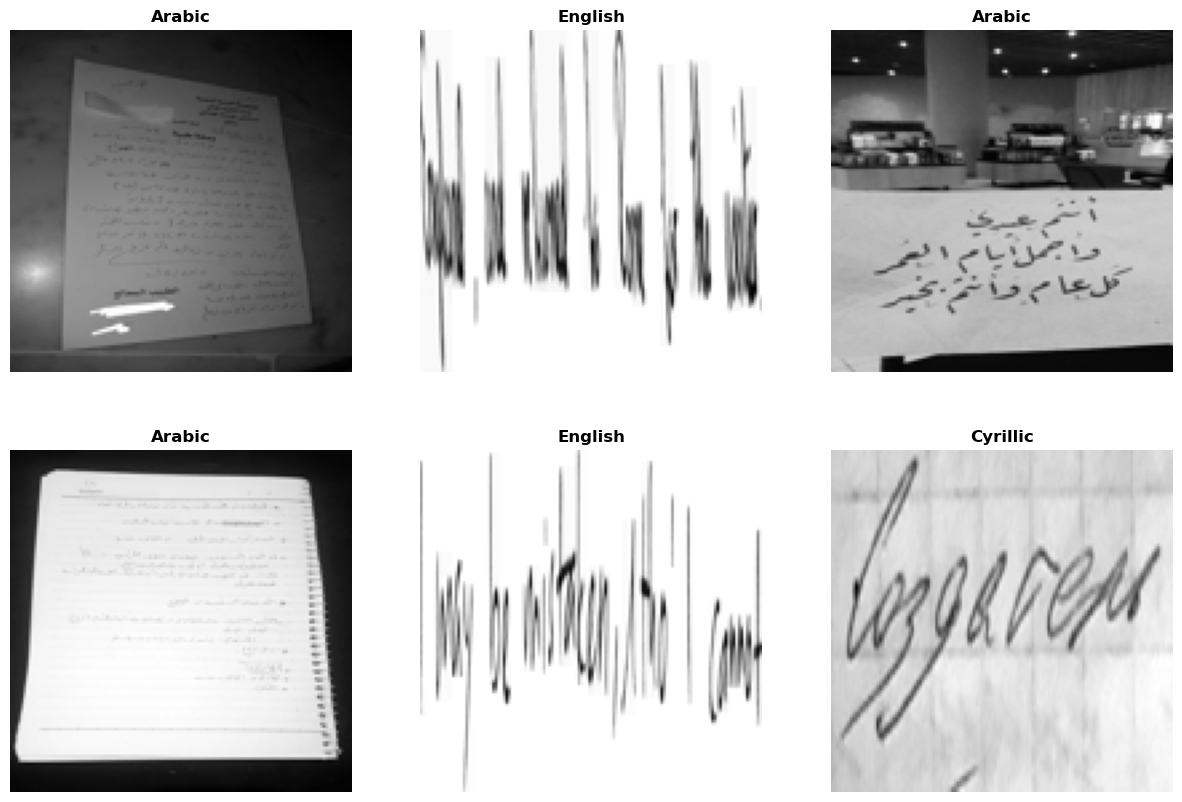

In [17]:
def visualize_sample_images(df, num_samples=6, img_height=128, img_width=128):
    """
    Visualize multiple random images from the dataset.
    
    Parameters:
    - df: DataFrame with 'image' and 'language' columns
    - num_samples: Number of images to display
    - img_height: Height of the image
    - img_width: Width of the image
    """
    
    sample_df = df.sample(n=min(num_samples, len(df)), random_state=42)
    
    rows = (num_samples + 2) // 3 
    cols = min(3, num_samples)
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    
    if num_samples == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if num_samples > 3 else axes
    
    for idx, (_, row) in enumerate(sample_df.iterrows()):
        if idx >= num_samples:
            break
            
        img_2d = row['image'].reshape(img_height, img_width)
        
        axes[idx].imshow(img_2d, cmap='gray')
        axes[idx].set_title(f"{row['language'].capitalize()}", fontsize=12, fontweight='bold')
        axes[idx].axis('off')
    
    plt.show()

visualize_sample_images(df, num_samples=6, img_height=128, img_width=128)

In [56]:
# exploded data for cnn
df_explode = pd.concat([pd.DataFrame(df['image'].to_list()), df['language']], axis=1)
df_explode.to_csv("data.csv", index=False)

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ipythonx/msratd500")

print("Path to dataset files:", path)

Path to dataset files: /Users/sasha/.cache/kagglehub/datasets/ipythonx/msratd500/versions/1
